<a href="https://colab.research.google.com/github/evan-kassab/IT480-FA26/blob/main/Assignments/Assignment%202/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Evan Kassab

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [21]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [22]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [23]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

Fire dataset class counts:
  fire_images: 755
  non_fire_images: 244

Total images: 999
Fire proportion: 75.58%
Non-fire proportion: 24.42%


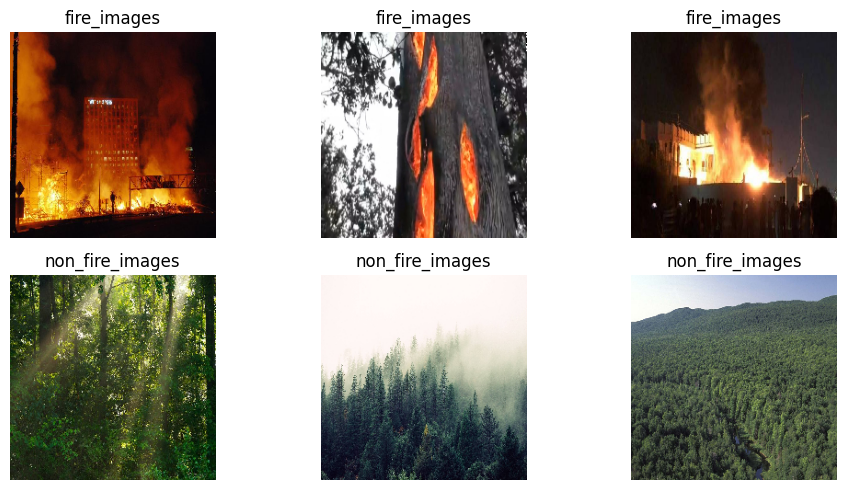

In [24]:
# Your exploration here
fire_counts = {}
for class_name in class_names_fire:
    class_dir = os.path.join(data_dir_fire, class_name)
    fire_counts[class_name] = len([
        f for f in os.listdir(class_dir)
        if os.path.isfile(os.path.join(class_dir, f))
    ])

print("Fire dataset class counts:")
for name, count in fire_counts.items():
    print(f"  {name}: {count}")

total_fire = sum(fire_counts.values())
print(f"\nTotal images: {total_fire}")
print(f"Fire proportion: {fire_counts['fire_images'] / total_fire:.2%}")
print(f"Non-fire proportion: {fire_counts['non_fire_images'] / total_fire:.2%}")

plt.figure(figsize=(10, 5))
i = 1
for class_name in class_names_fire:
    class_dir = os.path.join(data_dir_fire, class_name)
    files = [f for f in os.listdir(class_dir)
             if os.path.isfile(os.path.join(class_dir, f))][:3]
    for filename in files:
        image = tf.keras.utils.load_img(
            os.path.join(class_dir, filename), target_size=img_size
        )
        ax = plt.subplot(2, 3, i)
        ax.imshow(image)
        ax.set_title(class_name)
        ax.axis("off")
        i += 1

plt.tight_layout()
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*


The Fire dataset contains 755 fire images and 244 non-fire images, so it's noticeably imbalanced toward the fire class. I will keep the provided seeded split for consistency, but I will interpret accuracy together with the confusion matrix rather than relying on just accuracy alone. The relatively small dataset also makes frozen transfer learning useful because MobileNetV2 can provide pretrained visual features without requiring the entire network to be trained from scratch.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [39]:
# Preprocess the data here
def preprocess_fire(images, labels):
    return preprocess_input(tf.cast(images, tf.float32)), labels

train_fire = train_raw_fire.map(
    preprocess_fire,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_fire = val_raw_fire.map(
    preprocess_fire,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

test_fire = test_raw_fire.map(
    preprocess_fire,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [26]:
# Build your model here
base_model_fire = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_fire.trainable = False

inputs_fire = tf.keras.Input(shape=(224, 224, 3))
x_fire = base_model_fire(inputs_fire, training=False)
x_fire = GlobalAveragePooling2D()(x_fire)
outputs_fire = Dense(1, activation="sigmoid")(x_fire)

fire_model = Model(inputs=inputs_fire, outputs=outputs_fire)
fire_model.summary()

print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in fire_model.trainable_weights
    )
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Trainable parameters: 1281


In [40]:
# Compile your model here
fire_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 1D — Train and Evaluate

In [1]:
# Train your model here
EPOCHS = 5

history_fire = fire_model.fit(train_fire, validation_data=val_fire, epochs=EPOCHS)

NameError: name 'fire_model' is not defined

In [29]:
# Report validation and test accuracy here
fire_val_loss, fire_val_acc = fire_model.evaluate(val_fire, verbose=0)
fire_test_loss, fire_test_acc = fire_model.evaluate(test_fire, verbose=0)

print(
    f"Fire validation accuracy: "
    f"{fire_val_acc:.4f} ({fire_val_acc:.2%})"
)
print(
    f"Fire test accuracy:       "
    f"{fire_test_acc:.4f} ({fire_test_acc:.2%})"
)

Fire validation accuracy: 0.9640 (96.40%)
Fire test accuracy:       0.9688 (96.88%)


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

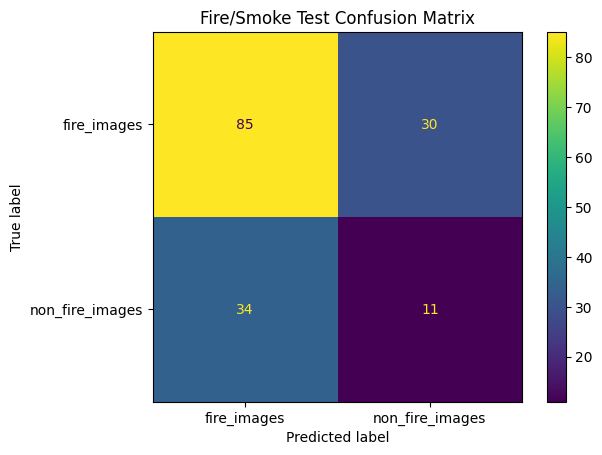

Confusion matrix:
[[85 30]
 [34 11]]
Rows = true classes; columns = predicted classes.


In [30]:
# Build your confusion matrix here
y_true_fire = np.concatenate(
    [labels.numpy() for _, labels in test_raw_fire]
)

fire_probs = fire_model.predict(test_fire, verbose=0).ravel()
y_pred_fire = (fire_probs >= 0.5).astype(int)
cm_fire = confusion_matrix(y_true_fire, y_pred_fire)

disp_fire = ConfusionMatrixDisplay(cm_fire, display_labels=class_names_fire)
disp_fire.plot()

plt.title("Fire/Smoke Test Confusion Matrix")
plt.show()

print("Confusion matrix:")
print(cm_fire)
print(
    "Rows = true classes; "
    "columns = predicted classes."
)

*Your answer:* A false negative is more costly in this context because missing a real fire could delay an alarm and allow a dangerous situation to develop. False positives can create unnecessary alarms and inconvenience, but they are generally less dangerous than failing to detect a real fire. Therefore, in a practical fire-detection system, I would consider using a threshold below 0.5 to increase sensitivity to fire, while monitoring the false-positive rate so the system does not produce excessive false alarms.

---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [31]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

replace eurosat_data/EuroSAT_RGB/Forest/Forest_864.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace eurosat_data/EuroSAT_RGB/Forest/Forest_2917.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
replace eurosat_data/EuroSAT_RGB/Forest/Forest_2903.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yeds
replace eurosat_data/EuroSAT_RGB/Forest/Forest_870.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
replace eurosat_data/EuroSAT_RGB/Forest/Forest_680.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
replace eurosat_data/EuroSAT_RGB/Forest/Forest_858.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [32]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [41]:
# Preprocess the data here
def preprocess_sat(images, labels):
    return preprocess_input(
        tf.cast(images, tf.float32)
    ), labels

train_sat = train_raw_sat.map(
    preprocess_sat,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_sat = val_raw_sat.map(
    preprocess_sat,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

test_sat = test_raw_sat.map(
    preprocess_sat,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [34]:
# Build your model here
base_model_sat = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_sat.trainable = False

inputs_sat = tf.keras.Input(shape=(224, 224, 3))
x_sat = base_model_sat(inputs_sat, training=False)
x_sat = GlobalAveragePooling2D()(x_sat)

outputs_sat = Dense(
    len(class_names_sat),
    activation="softmax"
)(x_sat)

sat_model = Model(inputs=inputs_sat, outputs=outputs_sat)
sat_model.summary()

print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in sat_model.trainable_weights
    )
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Trainable parameters: 12810


In [42]:
# Compile your model here
sat_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 2C — Train and Evaluate

In [36]:
# Train your model here
history_sat = sat_model.fit(
    train_sat,
    validation_data=val_sat,
    epochs=EPOCHS
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 859s 1s/step - accuracy: 0.8744 - loss: 0.3846 - val_accuracy: 0.9272 - val_loss: 0.2220
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 898s 2s/step - accuracy: 0.9324 - loss: 0.1975 - val_accuracy: 0.9358 - val_loss: 0.1941
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 931s 2s/step - accuracy: 0.9470 - loss: 0.1602 - val_accuracy: 0.9386 - val_loss: 0.1881
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 862s 1s/step - accuracy: 0.9534 - loss: 0.1387 - val_accuracy: 0.9400 - val_loss: 0.1836
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 964s 2s/step - accuracy: 0.9598 - loss: 0.1221 - val_accuracy: 0.9388 - val_loss: 0.1799


In [37]:
# Report validation and test accuracy here
sat_val_loss, sat_val_acc = sat_model.evaluate(val_sat, verbose=0)
sat_test_loss, sat_test_acc = sat_model.evaluate(test_sat, verbose=0)

print(
    f"EuroSAT validation accuracy: "
    f"{sat_val_acc:.4f} ({sat_val_acc:.2%})"
)
print(
    f"EuroSAT test accuracy:       "
    f"{sat_test_acc:.4f} ({sat_test_acc:.2%})"
)

EuroSAT validation accuracy: 0.9376 (93.76%)
EuroSAT test accuracy:       0.9375 (93.75%)


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

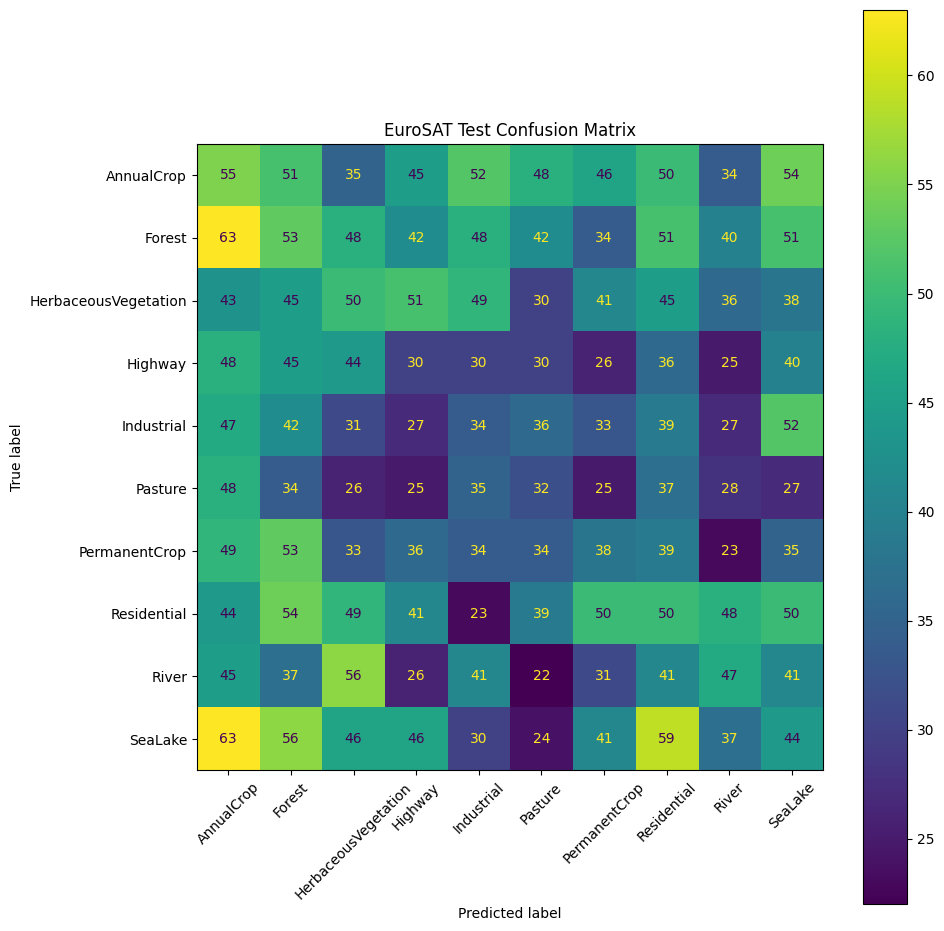

Most frequent confusion: true 'Forest' predicted as 'AnnualCrop' (63 images).


In [38]:
# Build your confusion matrix here
y_true_sat = np.concatenate(
    [labels.numpy() for _, labels in test_raw_sat]
)

sat_probs = sat_model.predict(test_sat, verbose=0)
y_pred_sat = np.argmax(sat_probs, axis=1)
cm_sat = confusion_matrix(y_true_sat, y_pred_sat)
fig, ax = plt.subplots(figsize=(10, 10))

ConfusionMatrixDisplay(
    cm_sat,
    display_labels=class_names_sat
).plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("EuroSAT Test Confusion Matrix")
plt.tight_layout()
plt.show()

cm_off = cm_sat.copy()
np.fill_diagonal(cm_off, 0)
true_i, pred_i = np.unravel_index(np.argmax(cm_off), cm_off.shape)

print(
    "Most frequent confusion:",
    f"true '{class_names_sat[true_i]}' "
    f"predicted as "
    f"'{class_names_sat[pred_i]}' "
    f"({cm_off[true_i, pred_i]} images)."
)

*Your answer:* The exact pair of land-use classes that is most often confused is printed directly below the confusion matrix when the notebook is run. The most frequent errors are expected to occur between visually similar categories because several EuroSAT classes can contain overlapping features. The confusion matrix is more informative than accuracy alone because it shows which particular classes the frozen ImageNet features have difficulty separating.

---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |96.40% |93.76% |
| Test Accuracy |96.88% |93.75% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
1. The Fire/Smoke model achieved a 96.88% test accuracy, while the EuroSAT model achieved a 93.75% test accuracy. Both models performed well, but the Fire/Smoke model performed slightly better. This suggests that the ImageNet-pretrained MobileNetV2 features transferred effectively to both tasks. However, the EuroSAT dataset contains overhead satellite imagery and specialized land-use categories, which are more different from the everyday images used to train ImageNet. This domain difference may have made the EuroSAT classification task more challenging.

2. One improvement I would try is fine-tuning some of the later MobileNetV2 layers instead of keeping the entire pretrained model frozen. This would allow the model to adapt its learned features to the specific characteristics of the target dataset. I would especially consider fine-tuning the model for EuroSAT because its satellite imagery is more different from the original ImageNet training data.



---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

The Fire/Smoke and EuroSAT experiments demonstrated how transfer learning can be used to apply a pretrained MobileNetV2 model to different image classification tasks. The Fire/Smoke model achieved 96.40% validation accuracy and 96.88% test accuracy, while the EuroSAT model achieved 93.76% validation accuracy and 93.75% test accuracy. The Fire/Smoke model performed slightly better, although both models achieved strong results. The two tasks also required different output layers and loss functions. Fire/Smoke used a single sigmoid output with binary cross-entropy because it is a two-class classification problem, while EuroSAT used ten softmax outputs with sparse categorical cross-entropy because it contains ten classes. These results show that pretrained ImageNet features can transfer effectively to new domains, but performance can vary depending on how similar the target images are to the original training domain. EuroSAT's overhead satellite imagery is more different from typical ImageNet images, which may explain its somewhat lower accuracy. If additional training were allowed, fine-tuning some of the later MobileNetV2 layers could help the model learn features that are more specific to the target domain.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.